In [ ]:
## Anandhan R - 2025166043 (Lab Assessment Answer Sheet 1st December 2025)

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
from scipy import stats
import matplotlib.pyplot as plt


In [85]:
file_path = "hospitaldata.csv"
data = pd.read_csv(file_path)
df = pd.DataFrame(data)



In [86]:
# 1 - 1A First 10 Rows and Last 10 Rows
print("First 10 Rows\n")
print(df.head(10))
print("\nLast 10 Rows\n")
print(df.tail(10))

First 10 Rows

   stage              Trt                    Status   Age     wt  hx  sbp  \
0      4          placebo        dead - prostaticca  60.0  134.0   1   16   
1      3  0.2 mg estrogen      dead - unknown cause   NaN  107.0   0   14   
2      3  5.0 mg estrogen  dead - heart or vascular  73.0  111.0   1   15   
3      3          placebo        dead - prostaticca  61.0  109.0   0   14   
4      3          placebo  dead - heart or vascular  76.0   90.0   0   13   
5      4  0.2 mg estrogen        dead - prostaticca  51.0  100.0   0   16   
6      4          placebo  dead - heart or vascular  72.0   83.0   1   14   
7      4  1.0 mg estrogen        dead - prostaticca   NaN   88.0   1   12   
8      4  5.0 mg estrogen  dead - heart or vascular  72.0  110.0   0   14   
9      4  5.0 mg estrogen        dead - prostaticca  80.0  105.0   1   14   

   dbp    sz    sg        Date  
0    8   9.0  13.0   3/22/1979  
1    9   8.0   9.0    9/7/1977  
2    8   NaN   9.0  10/27/1979  
3    

In [87]:
# 1 - 1B Identify missing values and handle them mean value
print("Missing Values: ")
print(df.isna().sum())
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['sz'] = df['sz'].fillna(df['sz'].mean())
df['wt'] = df['wt'].fillna(df['Age'].mean())
df['sg'] = df['sg'].fillna(df['sg'].mean())

print(df)

Missing Values: 
stage     0
Trt       0
Status    0
Age       2
wt        1
hx        0
sbp       0
dbp       0
sz        3
sg        3
Date      0
dtype: int64
    stage              Trt                    Status        Age          wt  \
0       4          placebo        dead - prostaticca  60.000000  134.000000   
1       3  0.2 mg estrogen      dead - unknown cause  70.833333  107.000000   
2       3  5.0 mg estrogen  dead - heart or vascular  73.000000  111.000000   
3       3          placebo        dead - prostaticca  61.000000  109.000000   
4       3          placebo  dead - heart or vascular  76.000000   90.000000   
5       4  0.2 mg estrogen        dead - prostaticca  51.000000  100.000000   
6       4          placebo  dead - heart or vascular  72.000000   83.000000   
7       4  1.0 mg estrogen        dead - prostaticca  70.833333   88.000000   
8       4  5.0 mg estrogen  dead - heart or vascular  72.000000  110.000000   
9       4  5.0 mg estrogen        dead - prostat

In [88]:
# 1 - 1C Remove duplicates row from the dataset
df = df.drop_duplicates()
print(df)

    stage              Trt                    Status        Age          wt  \
0       4          placebo        dead - prostaticca  60.000000  134.000000   
1       3  0.2 mg estrogen      dead - unknown cause  70.833333  107.000000   
2       3  5.0 mg estrogen  dead - heart or vascular  73.000000  111.000000   
3       3          placebo        dead - prostaticca  61.000000  109.000000   
4       3          placebo  dead - heart or vascular  76.000000   90.000000   
5       4  0.2 mg estrogen        dead - prostaticca  51.000000  100.000000   
6       4          placebo  dead - heart or vascular  72.000000   83.000000   
7       4  1.0 mg estrogen        dead - prostaticca  70.833333   88.000000   
8       4  5.0 mg estrogen  dead - heart or vascular  72.000000  110.000000   
9       4  5.0 mg estrogen        dead - prostaticca  80.000000  105.000000   
10      4  5.0 mg estrogen    dead - cerebrovascular  69.000000   71.000000   
11      4  1.0 mg estrogen                     alive

In [89]:
# 1 - 1 d Convert a data column into day, month, and year components
df["month"] = df["Date"].apply(lambda x: x.split("/")[0])
df["year"] = df["Date"].apply(lambda x: x.split("/")[2])
df["day"] = df["Date"].apply(lambda x: x.split("/")[1])

print(df.head())

   stage              Trt                    Status        Age     wt  hx  \
0      4          placebo        dead - prostaticca  60.000000  134.0   1   
1      3  0.2 mg estrogen      dead - unknown cause  70.833333  107.0   0   
2      3  5.0 mg estrogen  dead - heart or vascular  73.000000  111.0   1   
3      3          placebo        dead - prostaticca  61.000000  109.0   0   
4      3          placebo  dead - heart or vascular  76.000000   90.0   0   

   sbp  dbp         sz    sg        Date month  year day  
0   16    8   9.000000  13.0   3/22/1979     3  1979  22  
1   14    9   8.000000   9.0    9/7/1977     9  1977   7  
2   15    8  10.352941   9.0  10/27/1979    10  1979  27  
3   14    9   3.000000  11.0   12/8/1977    12  1977   8  
4   13    8   5.000000  10.0   2/19/1979     2  1979  19  


In [90]:
# 1 - 1 E Add a new column by combining two existing columns
df['BMI'] = df['wt'] - df['Age']
print(df.head())

   stage              Trt                    Status        Age     wt  hx  \
0      4          placebo        dead - prostaticca  60.000000  134.0   1   
1      3  0.2 mg estrogen      dead - unknown cause  70.833333  107.0   0   
2      3  5.0 mg estrogen  dead - heart or vascular  73.000000  111.0   1   
3      3          placebo        dead - prostaticca  61.000000  109.0   0   
4      3          placebo  dead - heart or vascular  76.000000   90.0   0   

   sbp  dbp         sz    sg        Date month  year day        BMI  
0   16    8   9.000000  13.0   3/22/1979     3  1979  22  74.000000  
1   14    9   8.000000   9.0    9/7/1977     9  1977   7  36.166667  
2   15    8  10.352941   9.0  10/27/1979    10  1979  27  38.000000  
3   14    9   3.000000  11.0   12/8/1977    12  1977   8  48.000000  
4   13    8   5.000000  10.0   2/19/1979     2  1979  19  14.000000  


In [91]:
# 2 A Count total alive patients
print("Total Alive Patients: ", df[df['Status'].str.contains('alive', case=False, na=False)].shape[0])

Total Alive Patients:  5


In [92]:
# 2 B Display summary statistics
df.describe()

,stage,Age,wt,hx,sbp,dbp,sz,sg,BMI
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,3.500000,70.833333,100.891667,0.450000,14.850000,8.350000,10.352941,10.117647,30.058333
std,0.512989,7.102631,15.416657,0.510418,3.869925,2.518876,7.704689,1.970369,17.036105
min,3.000000,51.000000,70.833333,0.000000,11.000000,6.000000,1.000000,5.000000,2.000000
25%,3.000000,68.750000,92.250000,0.000000,14.000000,7.000000,5.750000,9.000000,16.875000
50%,3.500000,72.500000,102.500000,0.000000,14.000000,8.000000,8.500000,10.058824,30.000000
75%,4.000000,76.000000,110.250000,1.000000,15.000000,9.000000,10.514706,11.000000,38.750000
max,4.000000,80.000000,134.000000,1.000000,30.000000,18.000000,33.000000,13.000000,74.000000



Covariance Matrix:
           stage        Age          wt        hx        sbp       dbp  \
stage  0.263158  -1.078947   -1.793860  0.026316  -0.447368 -0.500000   
Age   -1.078947  50.447368   -1.054094  0.649123   1.535088  0.745614   
wt    -1.793860  -1.054094  237.673319  0.577632  18.939035  7.417105   
hx     0.026316   0.649123    0.577632  0.260526   0.386842  0.307895   
sbp   -0.447368   1.535088   18.939035  0.386842  14.976316  8.897368   
dbp   -0.500000   0.745614    7.417105  0.307895   8.897368  6.344737   
sz     1.359133  -3.872033  -49.646543 -0.201238  -2.365325 -5.427245   
sg     0.424149  -9.166667   -6.413313 -0.102167  -1.083591 -0.482972   
BMI   -0.714912 -51.501462  238.727412 -0.071491  17.403947  6.671491   

              sz        sg         BMI  
stage   1.359133  0.424149   -0.714912  
Age    -3.872033 -9.166667  -51.501462  
wt    -49.646543 -6.413313  238.727412  
hx     -0.201238 -0.102167   -0.071491  
sbp    -2.365325 -1.083591   17.403947  
db

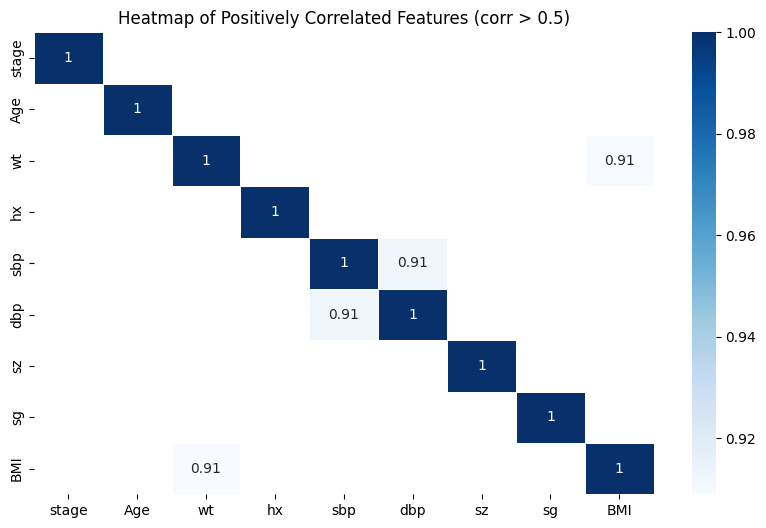

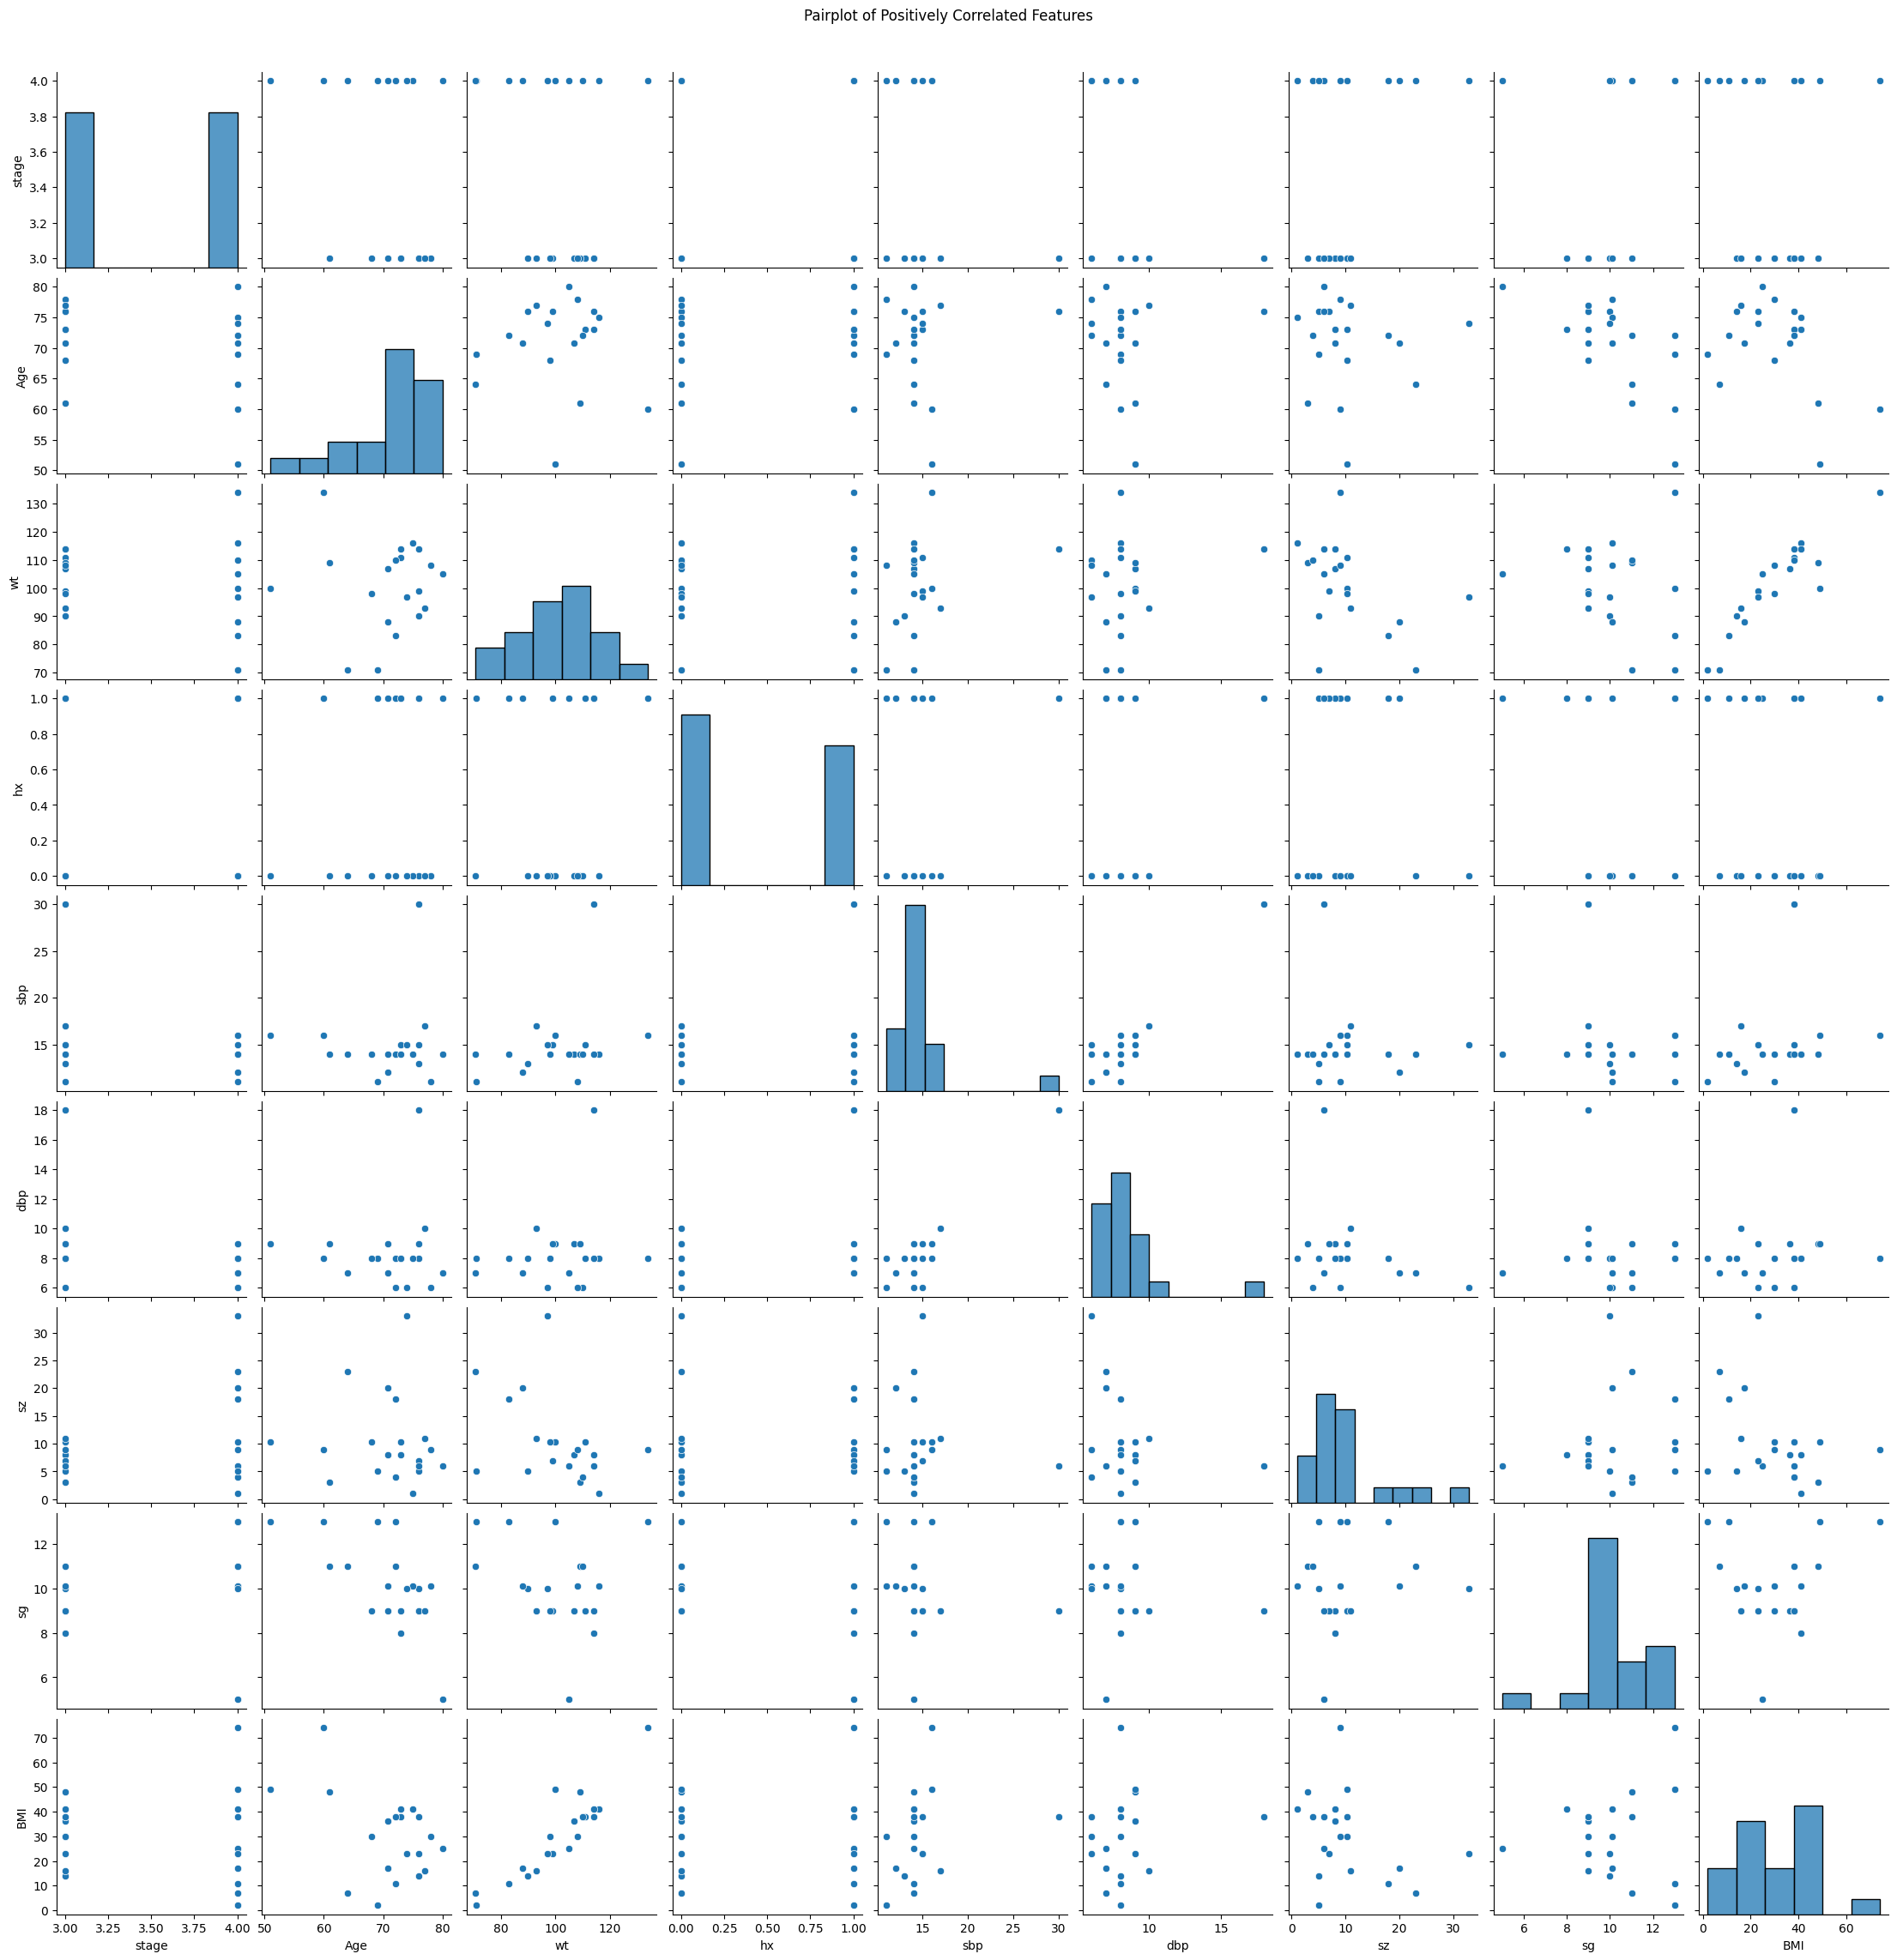

In [93]:
# 2 C Find Covariance and Correrlation between features and visualize the postive correlated features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_num = df[numeric_cols]

cov_matrix = df_num.cov()
print("\nCovariance Matrix:\n", cov_matrix)

corr_matrix = df_num.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

positive_corr = corr_matrix[corr_matrix > 0.5]
print("\nPositively Correlated Features (corr > 0.5):\n", positive_corr)

plt.figure(figsize=(10, 6))
sns.heatmap(positive_corr, annot=True, cmap="Blues", linewidths=0.5)
plt.title("Heatmap of Positively Correlated Features (corr > 0.5)")
plt.show()


pos_corr_features = positive_corr.dropna(how='all').columns.tolist()

if len(pos_corr_features) > 1:
    sns.pairplot(df_num[pos_corr_features])
    plt.suptitle("Pairplot of Positively Correlated Features", y=1.02)
    plt.show()
else:
    print("Not enough positively correlated features for pairplot.")


In [94]:
# 2 D Eigen Values and Eigen Vectors for Stage, Age, Wt
matrix = df[["stage", "Age", "wt"]].corr()
eigen_values, eigen_vectors = np.linalg.eig(matrix)
print("Eigen Value", eigen_values)
print("Eigen Vectors", eigen_vectors)

Eigen Value [0.622303   1.36840315 1.00929385]
Eigen Vectors [[-0.70267341 -0.7114807  -0.00672998]
 [-0.56203319  0.56082646 -0.6079411 ]
 [-0.43631271  0.42340157  0.7939536 ]]


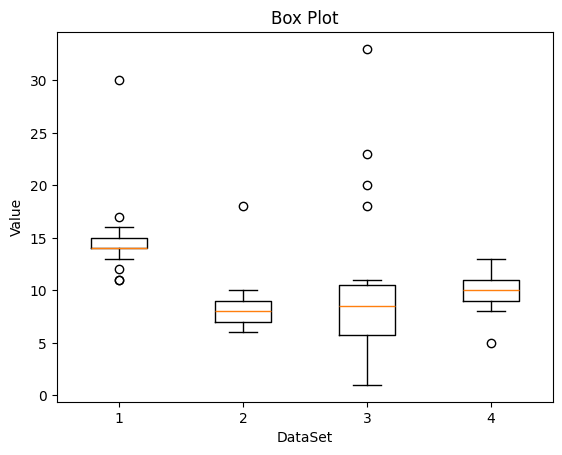


Rows before: 20
Rows after removing outliers: 9


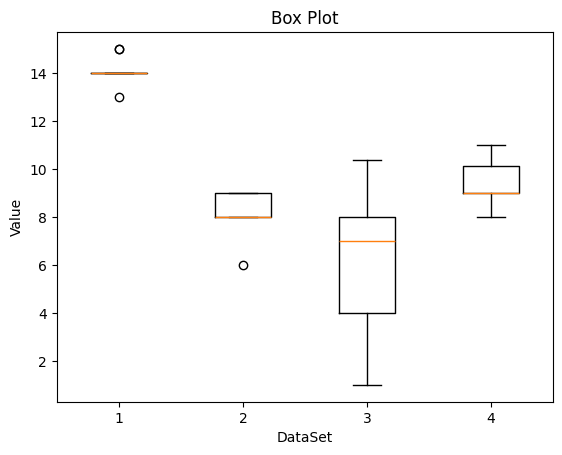

In [95]:
# 3 A Detect and remove outliers using the IQR method and draw boxplot

data = [df['sbp'], df['dbp'], df['sz'], df['sg']]

plt.boxplot(data)
plt.title("Box Plot")
plt.xlabel("DataSet")
plt.ylabel("Value")
plt.show()
print("\nRows before:", df.shape[0])
df_cleaned = df.copy()
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    

    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

data = [df_cleaned['sbp'], df_cleaned['dbp'], df_cleaned['sz'], df_cleaned['sg']]
print("Rows after removing outliers:", df_cleaned.shape[0])

plt.boxplot(data)
plt.title("Box Plot")
plt.xlabel("DataSet")
plt.ylabel("Value")
plt.show()



Normalized dataset:
   stage              Trt                    Status       Age        wt   hx  \
0    1.0          placebo        dead - prostaticca  0.310345  1.000000  1.0   
1    0.0  0.2 mg estrogen      dead - unknown cause  0.683908  0.572559  0.0   
2    0.0  5.0 mg estrogen  dead - heart or vascular  0.758621  0.635884  1.0   
3    0.0          placebo        dead - prostaticca  0.344828  0.604222  0.0   
4    0.0          placebo  dead - heart or vascular  0.862069  0.303430  0.0   

        sbp       dbp        sz     sg        Date month  year day       BMI  
0  0.263158  0.166667  0.250000  1.000   3/22/1979     3  1979  22  1.000000  
1  0.157895  0.250000  0.218750  0.500    9/7/1977     9  1977   7  0.474537  
2  0.210526  0.166667  0.292279  0.500  10/27/1979    10  1979  27  0.500000  
3  0.157895  0.250000  0.062500  0.750   12/8/1977    12  1977   8  0.638889  
4  0.105263  0.166667  0.125000  0.625   2/19/1979     2  1979  19  0.166667  


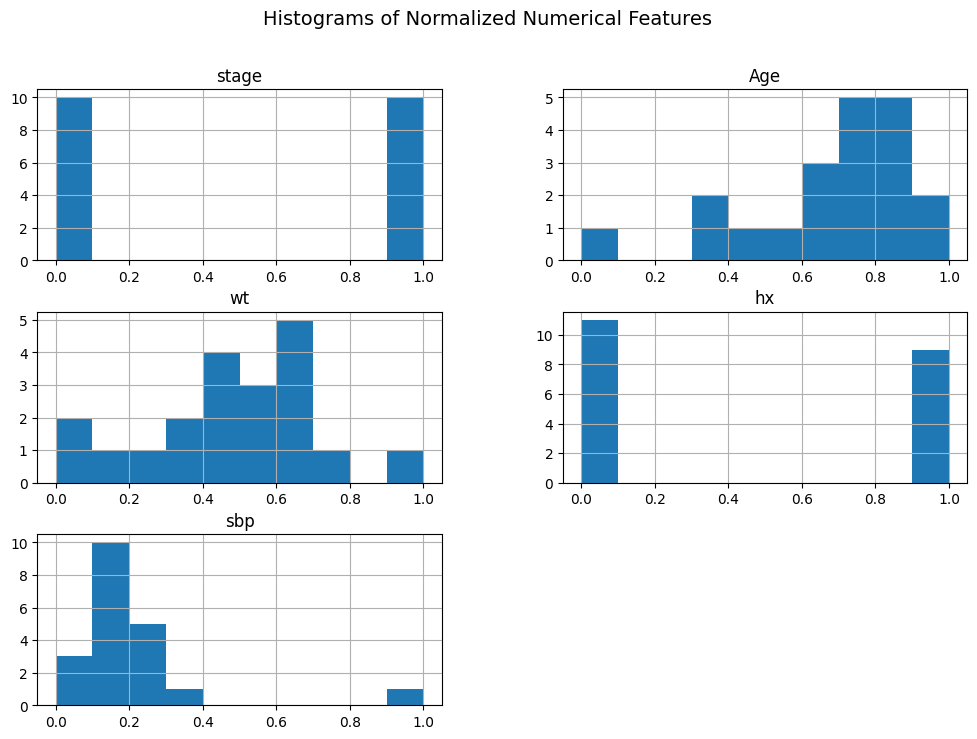

In [96]:
# 3 B Normalize all numeric columsn and using Min-Max Scaling and plot a histogram for any 5 numerical feature of the dataset.
df_normalized = df.copy()
df_normalized[numeric_cols] = (df[numeric_cols] - df[numeric_cols].min()) / (df[numeric_cols].max() - df[numeric_cols].min())

print("Normalized dataset:")
print(df_normalized.head())


cols_to_plot = numeric_cols[:5]   

df_normalized[cols_to_plot].hist(figsize=(12, 8), bins=10)
plt.suptitle("Histograms of Normalized Numerical Features", fontsize=14)
plt.show()


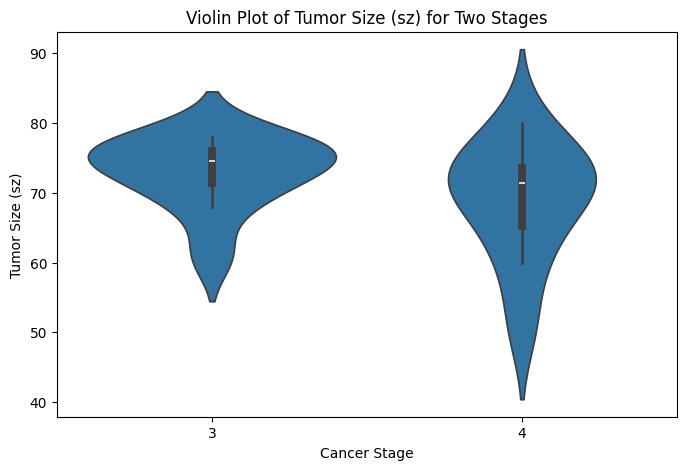

In [97]:
# 3 C Violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(df, x=df['stage'], y=df['Age'])
plt.title("Violin Plot of Tumor Size (sz) for Two Stages")
plt.xlabel("Cancer Stage")
plt.ylabel("Tumor Size (sz)")
plt.show()

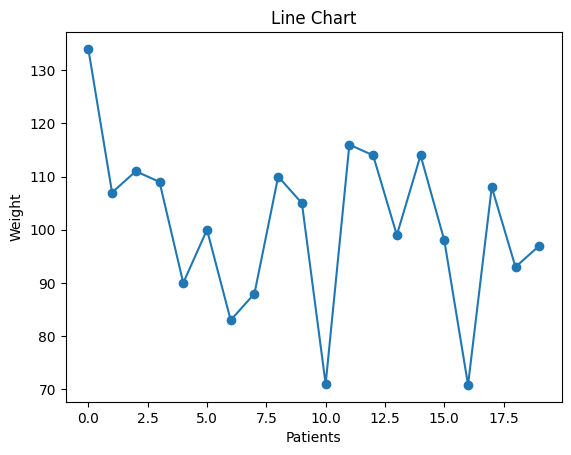

In [98]:
# 3 D Line plot for Wt
wt_data = df['wt']
plt.plot(wt_data,scalex=True, marker ='o')
plt.title("Line Chart")
plt.xlabel("Patients")
plt.ylabel("Weight")
plt.show()

In [99]:
# 3 e Anova Test if the mean of tumor size and age differs across cancer stages

from scipy.stats import f_oneway


# Group tumor size (sz) by cancer stage
tumor_groups = [grp["sz"].values for _, grp in df.groupby("stage")]

print(tumor_groups)

# Group age by cancer stage
age_groups = [grp["Age"].values for _, grp in df.groupby("stage")]

print(age_groups)

tumor_F, tumor_p = f_oneway(*tumor_groups)

print("ANOVA: Tumor Size (sz) Across Cancer Stages")
print("F-value:", tumor_F)
print("p-value:", tumor_p)


age_F, age_p = f_oneway(*age_groups)

print("\nANOVA: Age Across Cancer Stages")
print("F-value:", age_F)
print("p-value:", age_p)

def explain(p):
    return "Significant difference (p < 0.05)" if p < 0.05 else "No significant difference (p ≥ 0.05)"

print("\nInterpretation:")
print("Tumor Size →", explain(tumor_p))
print("Age        →", explain(age_p))

[array([ 8.        , 10.35294118,  3.        ,  5.        ,  8.        ,
        7.        ,  6.        , 10.35294118,  9.        , 11.        ]), array([ 9.        , 10.35294118, 18.        , 20.        ,  4.        ,
        6.        ,  5.        ,  1.        , 23.        , 33.        ])]
[array([70.83333333, 73.        , 61.        , 76.        , 73.        ,
       76.        , 76.        , 68.        , 78.        , 77.        ]), array([60.        , 51.        , 72.        , 70.83333333, 72.        ,
       80.        , 69.        , 75.        , 64.        , 74.        ])]
ANOVA: Tumor Size (sz) Across Cancer Stages
F-value: 2.4139258448968
p-value: 0.13766626017706235

ANOVA: Age Across Cancer Stages
F-value: 1.7301160729601461
p-value: 0.2049059293685092

Interpretation:
Tumor Size → No significant difference (p ≥ 0.05)
Age        → No significant difference (p ≥ 0.05)


Slope (m): 1.9800000000000002
Intercept (c): -2.0000000000000044
R² Score: 0.9768763081829961
Regression line fits the data VERY well.


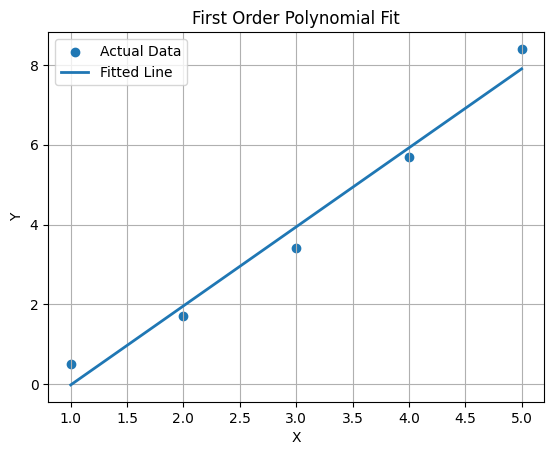

In [100]:
# 4. Fit a First order polynomial to the following data and Decide a regression line fits good or not?
# X: 1,2,3,4,5
# Y: 0.5,1.7,3.4,5.7,8.4

from sklearn.metrics import r2_score

# Given data
X = np.array([1, 2, 3, 4, 5])
Y = np.array([0.5, 1.7, 3.4, 5.7, 8.4])

# Fit first-order polynomial (linear regression)
coefficients = np.polyfit(X, Y, 1)  # 1 -> first-order
m, c = coefficients
print("Slope (m):", m)
print("Intercept (c):", c)

# Predicted values
Y_pred = np.polyval(coefficients, X)

# Calculate R^2 value
r2 = r2_score(Y, Y_pred)
print("R² Score:", r2)

# Check goodness of fit
if r2 > 0.95:
    print("Regression line fits the data VERY well.")
elif r2 > 0.80:
    print("Regression line fits the data reasonably well.")
else:
    print("Regression line does NOT fit the data well.")

# Plotting
plt.scatter(X, Y, label='Actual Data')
plt.plot(X, Y_pred, label='Fitted Line', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('First Order Polynomial Fit')
plt.legend()
plt.grid()
plt.show()
